# Problemas de regresión lineal: 

## Problema 1: Ley de Hubble 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
#Leer CSV
df = pd.read_csv("hubble.csv")
print(df.head())

      Name  N_measurements  velocity  mean_m
0    Virgo               7       890    12.5
1  Pegasus               5      3810    15.5
2   Pisces               4      4630    15.4
3   Cancer               2      4820    16.0
4  Perseus               4      5230    16.4


In [ ]:
#Datos
import numpy as np

M = -13.8

df["distance"] = 10**((df["mean_m"] - M + 5)/5)

print(df.head())

from sklearn.linear_model import LinearRegression

X = df[["distance"]]
y = df["velocity"]

model = LinearRegression(fit_intercept=False)
model.fit(X, y)

H0 = model.coef_[0]

print("H0 =", H0)

      Name  N_measurements  velocity  mean_m      distance
0    Virgo               7       890    12.5  1.819701e+06
1  Pegasus               5      3810    15.5  7.244360e+06
2   Pisces               4      4630    15.4  6.918310e+06
3   Cancer               2      4820    16.0  9.120108e+06
4  Perseus               4      5230    16.4  1.096478e+07
H0 = 0.0005319332349587794


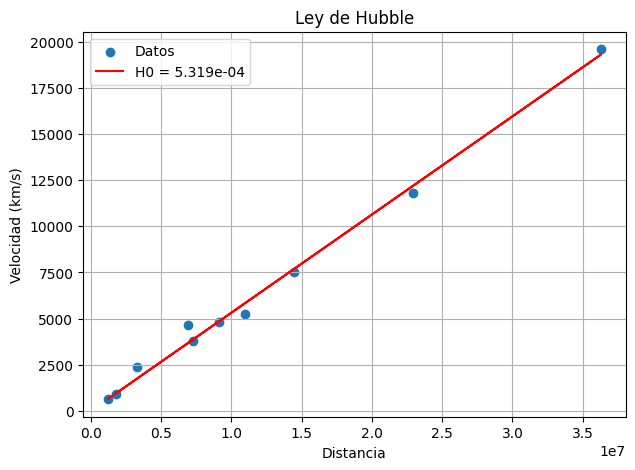

R² = 0.993657657015712


In [10]:
#Gráfcia comparativa 
y_pred = model.predict(X)

plt.figure(figsize=(7,5))
plt.scatter(df["distance"], df["velocity"], label="Datos")
plt.plot(df["distance"], y_pred,
         color="red",
         label=f"H0 = {H0:.3e}")

plt.xlabel("Distancia")
plt.ylabel("Velocidad (km/s)")
plt.title("Ley de Hubble")
plt.legend()
plt.grid()
plt.show()

print("R² =", r2_score(y, y_pred))

Se realizó un ajuste lineal entre la velocidad radial y la distancia estimada a partir de las magnitudes aparentes. La relación encontrada es altamente lineal, con un coeficiente de determinación $R^2=0.994$, 
lo que confirma la correlación observada originalmente por Hubble entre distancia y velocidad de recesión. La pendiente obtenida corresponde a una estimación de la constante de Hubble en las unidades empleadas por el conjunto de datos.
Seguramente la discrepancia se deba a un tema de unidades o a algún detalle menor en los datos, el hecho de que se ajusta bien a los datos me da más seguridad. No puedo encontrar el notebook correspondiente a esa clase para corroborar usar el M indicado o la basede datos indicada.

# Problema 2: Agujeros Negros Supermasivos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import ascii

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error
)

from sklearn.model_selection import train_test_split

from scipy.integrate import quad

plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["axes.grid"] = True

In [2]:
# Funciones auxiliares

def resumen_dataframe(df, nombre):

    print("="*50)
    print(nombre)
    print("="*50)
    print(f"Filas    : {df.shape[0]}")
    print(f"Columnas : {df.shape[1]}")
    print()

    display(df.head())


def ajustar_recta(X, y):

    modelo = LinearRegression()

    modelo.fit(
        X.reshape(-1,1),
        y
    )

    pendiente = modelo.coef_[0]
    intercepto = modelo.intercept_

    return modelo, pendiente, intercepto


def evaluar_modelo(modelo, X, y, test_sizes):

    resultados = []

    for tamaño in test_sizes:

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=tamaño,
            random_state=89
        )

        modelo.fit(X_train, y_train)

        pred = modelo.predict(X_test)

        resultados.append(
            r2_score(y_test, pred)
        )

    return np.array(resultados)

In [ ]:
# Cargar el catálogo

tabla = ascii.read(
    "data/SMBHData/table1.dat",
    readme="data/SMBHData/ReadMe"
)

datos = tabla.to_pandas()

resumen_dataframe(
    datos,
    "Catálogo SMBH"
)

In [ ]:
# Seleccionar variables de interés

datos_modelo = datos[
    ["logM", "sigma*", "FWHM", "z"]
].copy()

datos_modelo = datos_modelo.replace(
    [np.inf, -np.inf],
    np.nan
)

datos_modelo = datos_modelo.dropna()

print(datos_modelo.shape)

datos_modelo.head()

# NO HE CREADO LA CARPETA, ASÍ COMO ESTÁ NO FUNCIONA, SIGO MAÑANA

# Problema 3: Supernovas 